# TP2 — ISAC distribué : perception coopérative et diffusion sélective sous contraintes  (CORRIGÉ)


### Module ISAC — réseaux véhiculaires coopératifs

**Comment travailler ce TP**
- Exécuter les cellules **dans l'ordre** (Maj+Entrée).
- Compléter les zones `TODO`.
- Les blocs **Question** attendent une réponse écrite et argumentée.
- Le TP se déroule en deux parties, **A puis B**, qui s'enchaînent.

# Partie A — Percevoir l'environnement : le « S » de l'ISAC

Un véhicule **ISAC** (*Integrated Sensing and Communications*) ne fait pas que communiquer : il **perçoit** son environnement avec ses capteurs, puis **partage** ce qu'il a perçu. C'est l'union des deux qui crée une **perception collective** dépassant ce qu'un capteur voit seul.

Pour parler le langage des réseaux véhiculaires réels (standards **ETSI ITS-G5 / V2X**), on distingue trois types de messages, qu'on retrouvera tout au long du TP :

| Message | Rôle | Dans notre modèle |
|---|---|---|
| **CAM** (*Cooperative Awareness*) | chaque véhicule diffuse **périodiquement sa propre position** | la mobilité + le voisinage radio (graphe) |
| **DENM** (*Decentralized Environmental Notification*) | alerte **déclenchée par un danger** (accident, obstacle) | l'**accident critique** et les événements importants |
| **CPM** (*Collective Perception*) | un véhicule diffuse ce que **ses capteurs ont détecté** | le partage des événements perçus (cœur de l'ISAC) |

On travaille désormais sur une carte **1000×1000** : à cette échelle, propager une info à tout le réseau n'a plus de sens — on introduira donc une **zone de pertinence** par événement.

## 1. Le terrain de jeu : véhicules mobiles sur une grande carte

In [1]:
import numpy as np, networkx as nx, matplotlib.pyplot as plt, time
from IPython import display

tailleMap = 1000

def graphe_proximite(positions, R):
    G = nx.Graph(); N = len(positions)
    for i in range(N): G.add_node(i, pos=positions[i])
    for i in range(N):
        for j in range(i+1, N):
            if np.linalg.norm(positions[i]-positions[j]) <= R: G.add_edge(i, j)
    return G

def generer_positions(N, steps, vmax, tailleMap, seed=None):
    rng=np.random.default_rng(seed); pos=rng.random((N,2))*tailleMap
    vel=(rng.random((N,2))-0.5)*vmax; traj=[]
    for _ in range(steps):
        pos+=vel; hors=(pos<0)|(pos>tailleMap); vel[hors]*=-1
        pos=np.clip(pos,0,tailleMap); traj.append(pos.copy())
    return traj


## 2. Les événements : importance, durée de validité, et zone de pertinence

Chaque événement porte, en plus de son importance et de sa durée de validité (`ttl`), deux nouveautés :
- un **type** (`kind`) : `DENM` (danger déclenché) ou `CPM` (objet perçu) ;
- un **rayon de pertinence** (`relevance`) : la zone géographique au-delà de laquelle l'info n'intéresse plus personne. Un accident est pertinent loin (350 m), une flaque d'eau seulement localement (120 m). C'est ce qui **borne** la diffusion (principe du *geocast*).

In [2]:
class Event:
    def __init__(self, eid, x, y, importance, naissance, ttl, couleur, kind, relevance):
        self.id=eid; self.pos=np.array([x,y],dtype=float); self.importance=importance
        self.naissance=naissance; self.ttl=ttl; self.couleur=couleur
        self.kind=kind; self.relevance=relevance
    def actif(self, t): return self.naissance <= t < self.naissance + self.ttl

events = [
    Event(101, 300, 700, 0.9, naissance=0,  ttl=100, couleur='red',     kind='DENM', relevance=350),  # accident
    Event(201, 800, 200, 0.2, naissance=0,  ttl=100, couleur='skyblue', kind='CPM',  relevance=120),  # météo
    Event(202, 500, 500, 0.5, naissance=10, ttl=60,  couleur='orange',  kind='CPM',  relevance=180),  # ralentissement
    Event(203, 200, 400, 0.7, naissance=20, ttl=70,  couleur='purple',  kind='CPM',  relevance=250),  # obstacle
]
ACCIDENT_ID = 101
print('Événement', ACCIDENT_ID, '(accident) actif à t=75 ?', events[0].actif(75))



CATEGORIES = [('obstacle',0.7,'purple',55,'CPM',250),
              ('ralentissement',0.5,'orange',45,'CPM',180),
              ('meteo',0.2,'skyblue',90,'CPM',120)]

def make_events(n, steps, tailleMap, seed=None):
    # Initialisation du générateur de nombres aléatoires avec une graine optionnelle (pour la reproductibilité)
    rng = np.random.default_rng(seed)
    
    # Ajout systématique de l'événement majeur (l'accident critique avec ID 101) présent dès t=0 jusqu'à la fin
    evs = [Event(ACCIDENT_ID, 300, 700, 0.9, 0, steps, 'red', 'DENM', 350)]
    
    # Définition des poids pour les probabilités d'apparition des catégories d'événements (poids : 1, 2, 3)
    poids = np.array([1,2,3], float)
    poids /= poids.sum() # Normalisation pour obtenir des probabilités (somme égale à 1)
    
    # Boucle pour générer les n-1 autres événements aléatoires
    for k in range(n-1):
        # Sélection aléatoire d'une catégorie dans la liste CATEGORIES selon la pondération des poids
        lab, imp, col, ttl0, kind, rel = CATEGORIES[rng.choice(3, p=poids)]
        
        # Tirage de coordonnées géographiques (x, y) aléatoires réparties sur toute la carte
        x, y = rng.random(2)*tailleMap
        
        # Détermination d'une date de naissance aléatoire (au moins 30 pas de temps avant la fin du scénario)
        naissance = int(rng.integers(0, max(1, steps-30)))
        
        # Calcul du TTL (durée de vie) fluctuant de +/- 15 pas autour de la valeur de base, avec un minimum de 20 pas
        ttl = max(20, int(ttl0 + rng.integers(-15, 16)))
        
        # Instanciation de l'événement avec un identifiant unique (200, 201, 202...) et ajout à la liste
        evs.append(Event(200+k, x, y, imp, naissance, ttl, col, kind, rel))
        
    return evs


Événement 101 (accident) actif à t=75 ? True


## 3. Mesurer la perception (en tenant compte de la zone de pertinence)

Nous introduisons maintenant la métrique de la **perception collective pondérée**. Elle évalue l'efficacité globale de notre réseau en calculant la fraction de véhicules qui connaissent un événement, pondérée par la criticité de cet événement. 

Pour coller aux contraintes du monde réel, cette mesure intègre deux raffinements majeurs :

*   **Zone de pertinence (Géofencing) :** On ne compte, pour chaque événement, que les véhicules **concernés** (c'est-à-dire situés géographiquement dans son rayon de pertinence). Inutile de reprocher à une voiture à l'autre bout de la carte d'ignorer une flaque d'eau locale.
*   **Horodatage de l'information :** La mémoire d'un véhicule stocke, pour chaque info connue, son **instant d'observation** (`mem[i] = {event_id: t_observation}`). Cela permettra plus tard de calculer la fraîcheur ou l'**âge** de l'information (*Age of Information*).

---

### Formule Mathématique

À chaque pas de temps $t$, la perception collective pondérée $P(t)$ (exprimée en $\%$) est calculée sur l'ensemble des événements actifs $E_{\text{actifs}}$ selon la formule suivante :

$$P(t) = \frac{\sum_{e \in E_{\text{actifs}}} I_e \times X_e(t)}{\sum_{e \in E_{\text{actifs}}} I_e} \times 100$$

Où :
*   $I_e$ représente l'**importance** de l'événement $e$.
*   $X_e(t)$ représente le **taux de pénétration** de l'information uniquement auprès des véhicules situés dans la zone de pertinence à l'instant $t$ :


In [3]:
def pertinent(pos, e):
    return np.linalg.norm(pos - e.pos) <= e.relevance

def perception_ponderee(mem, events, traj_t, t, N):
    actifs=[e for e in events if e.actif(t)]
    if not actifs: return 100.0
    num=den=0.0
    for e in actifs:
        concernes=[i for i in range(N) if pertinent(traj_t[i], e)]
        if not concernes: continue
        part=sum(1 for i in concernes if e.id in mem[i])/len(concernes) #Calcule le taux de pénétration de l'information. On compte combien de véhicules de la liste concernes possèdent l'identifiant de l'événement (e.id) dans leur mémoire locale (mem[i]),
                                                                        #divisé par le nombre total de véhicules concernés
        num+=e.importance*part
        den+=e.importance
    return (num/den*100) if den else 100.0

def couverture_evenement(mem, eid, events, traj_t, t, N):
    # 1. Recherche et récupère l'événement correspondant à l'identifiant unique (eid) demandé
    e = next(x for x in events if x.id == eid)
    
    # 2. Si l'événement n'est pas actif à l'instant t (durée de vie expirée ou pas encore né), le score est de 0%
    if not e.actif(t): return 0.0
    
    # 3. Liste des indices des véhicules situés dans la zone de pertinence géographique de cet événement
    concernes = [i for i in range(N) if pertinent(traj_t[i], e)]
    
    # 4. Sécurité : si aucun véhicule ne se trouve dans la zone de pertinence, on retourne 0% pour éviter une division par zéro
    if not concernes: return 0.0
    
    # 5. Calcule le pourcentage de véhicules concernés qui possèdent l'information dans leur mémoire locale
    return sum(1 for i in concernes if eid in mem[i]) / len(concernes) * 100


## 4. L'intérêt de l'ISAC : capteur seul vs perception coopérative

Pourquoi marier capteur et communication ? On compare deux mondes sur exactement le même scénario : un réseau où chaque véhicule ne croit que ses propres capteurs, et un réseau ISAC où les véhicules partagent leurs perceptions (CPM).

In [4]:
def perception_capteur_seul(cfg, events, traj):
    """Perception si chaque véhicule n'utilise QUE son capteur (aucune communication)."""
    # 1. Extraction des paramètres : nombre de véhicules (N), pas de temps (steps) et rayon du capteur (R_sense)
    N, steps, R_sense = cfg['N'], cfg['steps'], cfg['R_sense']
    
    # 2. Initialisation de la mémoire locale vide pour chaque véhicule et de la liste historique des scores
    mem = {i: {} for i in range(N)}; hist = []
    
    # 3. Boucle principale qui parcourt chaque pas de temps t de la simulation
    for t in range(steps):
        # Récupération des positions des véhicules à l'instant t et de la liste des événements actifs
        positions = traj[t]; actifs = {e.id for e in events if e.actif(t)}
        
        # 4. Boucle pour mettre à jour la perception de chaque véhicule i
        for i in range(N):
            # Nettoyage de la mémoire : on supprime (oublie) les événements qui ne sont plus actifs à l'instant t
            mem[i] = {eid: ts for eid, ts in mem[i].items() if eid in actifs}
            
            # 5. Boucle de détection : le véhicule vérifie ce qu'il y a à portée de ses capteurs
            for e in events:
                # Si l'événement est actif et que la distance euclidienne véhicule-danger est inférieure au rayon du capteur
                if e.actif(t) and np.linalg.norm(positions[i] - e.pos) <= R_sense:
                    # Le véhicule enregistre l'événement dans sa mémoire avec l'instant d'observation courant t
                    mem[i][e.id] = t
                    
        # 6. Calcul du score de perception globale pondérée à cet instant t et ajout à l'historique
        hist.append(perception_ponderee(mem, events, positions, t, N))
        
    return hist

def perception_isac(cfg, events, traj):
    """Perception ISAC : capteur + partage (CPM) à tous les voisins, un saut par pas.
    Version sans contrainte (la Partie B ajoutera les budgets radio)."""
    # 1. Extraction des paramètres de configuration (Nombre de nœuds, pas de temps, portée radio R, portée capteur R_sense)
    N, steps, R, R_sense = cfg['N'], cfg['steps'], cfg['R'], cfg['R_sense']
    
    # 2. Initialisation des mémoires locales vides pour chaque véhicule et de l'historique global
    mem = {i: {} for i in range(N)}; hist = []
    
    # 3. Boucle principale temporelle sur chaque pas de temps t
    for t in range(steps):
        # Récupération des positions à l'instant t et de l'ensemble des identifiants des événements actifs
        positions = traj[t]; actifs = {e.id for e in events if e.actif(t)}
        
        # Indexation rapide des événements par leur ID pour un accès direct
        ebyid = {e.id: e for e in events}
        
        # 4. PHASE 1 : Nettoyage et Détection locale (Sensing) pour chaque véhicule
        for i in range(N):
            # Filtre Géocast : On oublie les événements expirés OU ceux dont le véhicule est sorti de la zone de pertinence
            mem[i] = {eid: ts for eid, ts in mem[i].items()
                      if eid in actifs and pertinent(positions[i], ebyid[eid])}
            
            # Détection capteur : Le véhicule vérifie s'il y a un événement actif sous ses yeux
            for e in events:
                if e.actif(t) and np.linalg.norm(positions[i] - e.pos) <= R_sense:
                    # Le véhicule note l'événement avec l'instant d'observation courant t
                    mem[i][e.id] = t
                    
        # 5. PHASE 2 : Communication V2X (Échanges radio)
        # Construction du graphe de proximité réseau à la portée radio R
        G = graphe_proximite(positions, R)
        
        # Création d'une copie temporaire des mémoires pour recevoir les messages sans altérer les émissions en cours
        new = {i: dict(mem[i]) for i in range(N)}
        
        # Boucle d'inondation (Flooding) : chaque émetteur i partage ses données
        for i in range(N):
            # Le véhicule i parcourt la liste de ses voisins radio directs j
            for j in G.neighbors(i):
                # Le véhicule i transmet toute sa base de connaissances au voisin j
                for eid, ts in mem[i].items():
                    # Filtre Géocast à la réception : Si le voisin j n'est pas concerné par l'info, le paquet est ignoré
                    if not pertinent(positions[j], ebyid[eid]): continue   
                    
                    # Fusion de données : Si le voisin j ignore l'info, ou si l'info reçue est plus fraîche, il met à jour sa mémoire
                    if eid not in new[j] or new[j][eid] < ts: new[j][eid] = ts
                    
        # Application des mémoires mises à jour pour le pas de temps suivant
        mem = new
        
        # 6. Enregistrement du score de performance globale pondérée à l'instant t
        hist.append(perception_ponderee(mem, events, positions, t, N))
        
    return hist

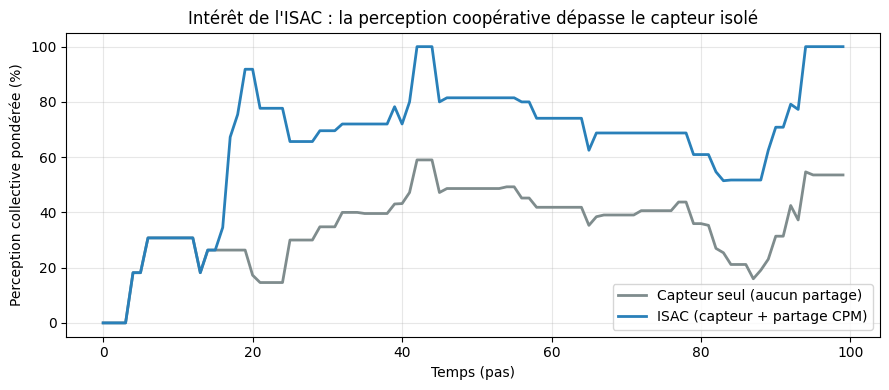

Perception moyenne capteur seul : 35.4 %
Perception moyenne ISAC         : 65.4 %
-> gain de l'ISAC : +30.0 points


In [5]:
# 1. Définition du dictionnaire de configuration pour ce scénario de démonstration
cfg_demo = dict(
    N=25,          # Nombre de véhicules sur la carte
    R=240,         # Portée radio de chaque véhicule (en mètres)
    R_sense=90,    # Portée des capteurs embarqués (en mètres)
    steps=100,     # Durée de la simulation (100 pas de temps)
    vmax=8         # Vitesse maximale des véhicules (en m/s)
)

# 2. Génération de la mobilité des 25 véhicules (graine 4 pour figer le hasard et pouvoir comparer)
traj = generer_positions(cfg_demo['N'], cfg_demo['steps'], cfg_demo['vmax'], tailleMap, seed=4)

# 3. Génération de 12 événements environnementaux (1 accident fixe + 11 aléatoires)
events = make_events(12, cfg_demo['steps'], tailleMap, seed=4)

# 4. Lancement des deux simulations comparatives
h_seul = perception_capteur_seul(cfg_demo, events, traj)  # Cas 1 : Aucun échange radio
h_isac = perception_isac(cfg_demo, events, traj)          # Cas 2 : Partage parfait (Flooding idéal)

# 5. Construction du graphique comparatif avec Matplotlib
plt.figure(figsize=(9, 4))
# Tracé de la courbe "Capteur seul" en gris
plt.plot(h_seul, label='Capteur seul (aucun partage)', color='#7f8c8d', linewidth=2)
# Tracé de la courbe "ISAC" en bleu
plt.plot(h_isac, label='ISAC (capteur + partage CPM)', color='#2980b9', linewidth=2)

plt.xlabel('Temps (pas)'); plt.ylabel('Perception collective pondérée (%)')
plt.title("Intérêt de l'ISAC : la perception coopérative dépasse le capteur isolé")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 6. Calcul et affichage des statistiques moyennes dans la console
print(f"Perception moyenne capteur seul : {np.mean(h_seul):.1f} %")
print(f"Perception moyenne ISAC         : {np.mean(h_isac):.1f} %")
print(f"-> gain de l'ISAC : +{np.mean(h_isac) - np.mean(h_seul):.1f} points")

### Question A

En une phrase, expliquez **pourquoi** la courbe ISAC passe au-dessus de la courbe « capteur seul ». Que connaît un véhicule en ISAC qu'il ne pourrait **jamais** percevoir seul ?

**Réponse attendue.** Avec l'ISAC, un véhicule apprend des événements **hors de portée de son propre capteur** (hors ligne de vue, trop loin) parce qu'un voisin les a détectés et partagés (CPM). La perception n'est plus limitée au rayon `R_sense` d'un seul véhicule mais devient **collective** : c'est exactement la valeur ajoutée de l'ISAC dans un réseau véhiculaire.

# Partie B — Choisir sous contraintes : valeur de l'information et diffusion sélective

 En Partie A, les véhicules partageaient **tout** ce qu'ils percevaient, sans limite. Irréaliste : une radio ne peut ni tout émettre, ni tout décoder. **Sous contrainte, il faut choisir quoi transmettre.** On compare trois stratégies — flooding, gossip et une diffusion **sélective** fondée sur la valeur de l'information — sur des régimes de difficulté croissante.

## 1. La valeur de l'information (VoI) et l'âge depuis l'observation

Pour décider quoi transmettre, on note chaque information par sa **valeur** :

$$\text{VoI} = \text{importance} \times \frac{1}{1 + \text{age}}$$

L'**âge** est le point subtil. Dans un vrai système de perception, l'âge se compte **depuis l'instant où l'information a été mesurée** (*Age of Information*), pas depuis la naissance physique de l'événement. Concrètement : quand un véhicule détecte un événement à l'instant `t`, il l'**horodate à `t`** ; ce timestamp **voyage avec le message** ; un récepteur calcule `age = t_courant - timestamp`. Si un véhicule re-détecte l'événement, il **rafraîchit** son horodatage. Deux véhicules peuvent donc détenir une information de **fraîcheur différente** sur le même événement — c'est ce que stocke `mem[i] = {event_id: t_observation}`.

In [6]:
def voi(importance, age):
    return importance * (1.0 / (1.0 + age))

# Test de la fonction pour un événement très important (importance = 0.9) à différents âges (0, 1, 5, 20 pas de temps)
for age in [0, 1, 5, 20]:
    print(f'importance=0.9, age={age:2d} -> VoI = {voi(0.9, age):.3f}')

print("La valeur de l'information (VoI) diminue à mesure que l'information vieillit.")

importance=0.9, age= 0 -> VoI = 0.900
importance=0.9, age= 1 -> VoI = 0.450
importance=0.9, age= 5 -> VoI = 0.150
importance=0.9, age=20 -> VoI = 0.043
La valeur de l'information (VoI) diminue à mesure que l'information vieillit.


## 2. Les contraintes radio :

On borne la radio de chaque véhicule par deux budgets, **identiques pour les trois protocoles** (même matériel) :
- `MAX_TX` : nombre maximal d'informations qu'un véhicule peut **émettre** par pas.
- `MAX_RX` : nombre maximal de paquets qu'il peut **retenir** par pas.

On mesure **trois coûts distincts**, et c'est important :
- l'**airtime** (`tx`) : le temps d'antenne consommé à l'émission ;

On ajoute aussi le **geocast** : on ne livre une info à un véhicule que s'il est dans la **zone de pertinence** de l'événement. Hors zone, le paquet n'est même pas transmis.

## 3. Trois façons de choisir quoi transmettre

À chaque pas, deux passes : **émission** (≤ `MAX_TX`) puis **réception** (≤ `MAX_RX` retenus).

- **Flooding** : émet au hasard, à **tous** les voisins ; à la réception, décode au hasard.
- **Gossip** : émet au hasard, à **un seul** voisin tiré au sort.
- **VoI sélectif** : émet ses infos de **plus forte valeur** ; à la réception, garde les plus précieuses 

In [7]:
# ================= ZONAGE & RSU MULTI-ZONES =================
# La carte est découpée en une grille grid x grid. Chaque cellule = une ZONE,
# avec UNE RSU plantée en son centre. grid=1 => une seule RSU centrale .

def make_rsus(grid, tailleMap):
    """Retourne (positions des RSU, bornes des zones). Une RSU au centre de chaque cellule."""
    # 1. Calcul de la taille (largeur et hauteur) d'une zone (cellule de la grille)
    cell = tailleMap / grid
    
    # Initialisation des listes pour stocker les coordonnées des RSU et les frontières des zones
    rsu_pos, zones = [], []
    
    # 2. Double boucle pour parcourir la grille en 2D (gy pour les lignes, gx pour les colonnes)
    for gy in range(grid):
        for gx in range(grid):
            # 3. Calcul et ajout des coordonnées (X, Y) du centre de la cellule pour y placer la RSU
            rsu_pos.append([(gx + 0.5) * cell, (gy + 0.5) * cell])
            
            # 4. Calcul et ajout des frontières de la zone sous forme de rectangle : (x_min, y_min, x_max, y_max)
            zones.append((gx * cell, gy * cell, (gx + 1) * cell, (gy + 1) * cell))   # (x0,y0,x1,y1)
            
    # 5. Retourne les positions sous forme de matrice Numpy et la liste des géométries des zones
    return np.array(rsu_pos, dtype=float), zones

    
def zone_of(pos, grid, tailleMap):
    """Cette fonction fait l'inverse de la précédente : elle prend la position en mètres d'un véhicule (ex: pos = [250, 750]) et dit instantanément dans quel numéro de zone (0, 1, 2 ou 3) il se trouve."""
    # 1. Calcul de la taille (largeur/hauteur) d'une zone en mètres
    cell = tailleMap/grid
    
    # 2. Calcul de l'index de colonne (gx) et de ligne (gy) dans la grille pour la position 'pos'
    gx = min(int(pos[0]//cell), grid-1)
    gy = min(int(pos[1]//cell), grid-1)
    
    # 3. Convertir les coordonnées 2D (gx, gy) en un numéro de zone unique (ID 1D)
    return gy*grid + gx

def cercle_touche_zone(e, zone):
    """Vrai si le cercle de pertinence de l'événement e atteint la zone (rectangle).
       C'est le 'pertinent()' transposé à l'échelle d'une zone -> règle du backbone."""
    # 1. Extraction des frontières de la zone (rectangle) : coins bas-gauche (x0, y0) et haut-droite (x1, y1)
    x0, y0, x1, y1 = zone
    
    # 2. Projection mathématique pour trouver les coordonnées (cx, cy) du point du rectangle LE PLUS PROCHE du centre de l'événement
    cx = min(max(e.pos[0], x0), x1)
    cy = min(max(e.pos[1], y0), y1)   
    
    # 3. Calcul de la distance euclidienne entre le centre de l'événement et ce point le plus proche (cx, cy)
    # Si cette distance est inférieure ou égale au rayon de pertinence, la zone est touchée (renvoie True)
    return np.hypot(e.pos[0]-cx, e.pos[1]-cy) <= e.relevance


def simuler(protocole, cfg, events, traj, use_rsu=False):
    """Simulation ISAC sous contraintes, avec RSU multi-zones optionnelles.
       Deux niveaux de diffusion :
         - NIVEAU 1 (intra-zone) : véhicule<->véhicule (protocole) + véhicule<->RSU de sa zone
         - NIVEAU 2 (backbone)   : RSU<->RSU, VoI-sélectif + filtre de pertinence-zone + portée R_RSU
       grid=1 reproduit  'RSU centrale unique'."""
    N, steps = cfg['N'], cfg['steps']
    R, R_sense = cfg['R'], cfg['R_sense']
    MAX_TX, MAX_RX = cfg['MAX_TX'], cfg['MAX_RX']
    ebyid = {e.id: e for e in events}

    grid   = cfg.get('grid', 1) if use_rsu else 0
    R_RSU  = cfg.get('R_RSU', 550)      # portée RSU (vers véhicules ET vers RSU voisines)
    RSU_TX = cfg.get('RSU_TX', 15)      # ce qu'une RSU annonce à chaque véhicule de sa zone
    RSU_RX = cfg.get('RSU_RX', 40)      # budget réception RSU (grand = "mémoire quasi illimitée")
    RSU_BB = cfg.get('RSU_BB_TX', 20)   # budget de relai sur le backbone (vers chaque RSU voisine)
    n_rsu  = grid*grid if use_rsu else 0
    rsu_pos, zones = (make_rsus(grid, tailleMap) if use_rsu else (np.empty((0,2)), []))

    mem = {i: {} for i in range(N+n_rsu)} #Les indices de 0 à N-1 correspondent aux véhicules.
                                          #Les indices de N à N + n_rsu - 1 correspondent aux RSU.
    cov, tx, crit, couleur_hist = [], [], [], []

    for t in range(steps):
        positions = traj[t]
        actifs = {e.id for e in events if e.actif(t)}

        # --- graphe du moment : v-v, v-RSU(de sa zone), RSU-RSU(backbone) ---
        G = graphe_proximite(positions, R)
        for r in range(n_rsu): G.add_node(N+r)
        if use_rsu:
            for i in range(N):                                   # véhicule -> RSU de SA zone
                r = zone_of(positions[i], grid, tailleMap)
                if np.linalg.norm(positions[i]-rsu_pos[r]) <= R_RSU: G.add_edge(i, N+r)
            for r in range(n_rsu):                               # backbone RSU - RSU
                for s in range(r+1, n_rsu):
                    if np.linalg.norm(rsu_pos[r]-rsu_pos[s]) <= R_RSU: G.add_edge(N+r, N+s)

        # (a) purge : véhicules = TTL + pertinence ; RSU = TTL + l'event touche sa zone
        """Nettoyage : on ne garde que les événements actifs et pertinents.
           - Véhicules : garde si l'event est encore actif et dans la zone de portée.
           - RSU : garde si l'event est encore actif le halo de l'événement touche la zone."""
        for i in range(N):
            mem[i] = {eid: ts for eid, ts in mem[i].items()
                      if eid in actifs and pertinent(positions[i], ebyid[eid])}
        for r in range(n_rsu):
            mem[N+r] = {eid: ts for eid, ts in mem[N+r].items()
                        if eid in actifs and cercle_touche_zone(ebyid[eid], zones[r])}

        
        # (b) sensing local 
        """Détection directe : si un véhicule est dans la portée R_sense, 
           il apprend l'événement et marque l'instant t comme temps d'observation."""
        direct = set()
        for i in range(N):
            for e in events:
                if e.actif(t) and np.linalg.norm(positions[i]-e.pos) <= R_sense:
                    mem[i][e.id] = t
                    direct.add(i)

        # (c) passe 1 : préparer les outbox
        """Tri des messages par VoI (Valeur de l'Information) : 
           on ne garde que les plus prioritaires dans la limite du budget TX."""
        
        outbox_v = {}
        for i in range(N):
            connus = [{'id':eid,'ts':ts,'voi':voi(ebyid[eid].importance, t-ts)}
                      for eid, ts in mem[i].items()]
            if protocole=='voi':
                outbox_v[i] = sorted(connus, key=lambda x:x['voi'], reverse=True)[:MAX_TX] # On fait un Tri par voI décroissant
            else:
                np.random.shuffle(connus)
                outbox_v[i] = connus[:MAX_TX]
                
        outbox_r = {}                                            # les RSU émettent TOUJOURS en VoI
        for r in range(n_rsu):
            connus = [{'id':eid,'ts':ts,'voi':voi(ebyid[eid].importance, t-ts)}
                      for eid, ts in mem[N+r].items()]
            outbox_r[N+r] = sorted(connus, key=lambda x:x['voi'], reverse=True)

        
        # (c) passe 2 : distribution dans des inbox
        """Transfert des messages : on simule l'envoi radio vers les voisins.
           - V2V : envoi aux véhicules à portée radio.
           - RSU : envoi sur backbone (backbone) ou vers les véhicules de la zone."""
        new_mem = {i: dict(mem[i]) for i in range(N+n_rsu)}
        inbox = {j: [] for j in range(N+n_rsu)}
        tx_count = 0

        # canal V2V (protocole + geocast)
        for i in range(N):
            if not outbox_v[i]: continue
            voisins = [j for j in G.neighbors(i) if j < N]
            if not voisins: continue
            cibles = [voisins[np.random.randint(len(voisins))]] if protocole=='gossip' else voisins  #Rappel : Gossip est le seul qui transmet à un seul voisin au hasard
            for j in cibles:
                for msg in outbox_v[i]:
                    # Filtre de pertinence : inutile d'envoyer si le voisin n'est pas concerné
                    if not pertinent(positions[j], ebyid[msg['id']]): continue
                    tx_count += 1
                    inbox[j].append(msg)

        if use_rsu:
            # canal V2I : chaque véhicule REMONTE à la RSU de sa zone (si l'event touche la zone)
            for i in range(N):
                r = zone_of(positions[i], grid, tailleMap)
                if not G.has_edge(i, N+r): continue
                for msg in outbox_v[i]:
                    # Filtre intelligent : on n'envoie que si c'est utile
                    if not cercle_touche_zone(ebyid[msg['id']], zones[r]): continue
                    tx_count += 1
                    inbox[N+r].append(msg)
                    
            # canal BACKBONE : RSU -> RSU voisine
            for r in range(n_rsu): # On prend chaque RSU source
                if not outbox_r[N+r]: continue
                for s in range(n_rsu): # On regarde toutes les autres RSU cibles
                    # On vérifie : 
                    # - s != r : on ne s'envoie pas de messages à soi-même
                    # - G.has_edge : existe-t-il une liaison filaire entre ces deux RSU ?
                    if s==r or not G.has_edge(N+r, N+s): continue
                    
                    # Budget limité par RSU_BB
                    for msg in outbox_r[N+r][:RSU_BB]:
                        if not cercle_touche_zone(ebyid[msg['id']], zones[s]): continue                         
                        tx_count += 1
                        inbox[N+s].append(msg)

                        
            # canal I2V : la RSU REDIFFUSE à ses véhicules (geocast)
            for r in range(n_rsu):
                if not outbox_r[N+r]: continue
                for i in range(N):
                    if zone_of(positions[i], grid, tailleMap)!=r or not G.has_edge(i, N+r): continue
                    for msg in outbox_r[N+r][:RSU_TX]:
                        if not pertinent(positions[i], ebyid[msg['id']]): continue
                        tx_count += 1
                        inbox[i].append(msg)

        # (c) passe 2 : réception (budget + VoI/hasard)
  
        for j in range(N+n_rsu):
            paquets = inbox[j]
            if not paquets: continue
            is_rsu = j >= N # True si j est une rsu  ( Rappel : de 0 à N-1 ce sont des véhicules ) 
            mode_voi = (protocole=='voi') or is_rsu          # les RSU trient toujours par valeur
            brx = RSU_RX if is_rsu else MAX_RX # budget de reception
            if mode_voi:
                meilleur = {}
                for msg in paquets:
                    # Filtrage intelligent 
                    eid = msg['id']
                    cur_ts = mem[j].get(eid, -1)
                    if msg['ts'] <= cur_ts: continue
                    if eid not in meilleur or msg['ts'] > meilleur[eid]['ts']:
                        meilleur[eid] = msg
                for msg in meilleur.values():
                    msg['voi_actuelle'] = voi(ebyid[msg['id']].importance, t - msg['ts'])
                gardes = sorted(meilleur.values(), key=lambda x:x['voi_actuelle'], reverse=True)[:brx]
            else:
                np.random.shuffle(paquets); gardes = paquets[:brx]

            for msg in gardes:
                cur = new_mem[j].get(msg['id'])
                if cur is None or cur < msg['ts']:
                    new_mem[j][msg['id']] = msg['ts']

        mem = new_mem
        tx.append(tx_count)
        cov.append(perception_ponderee(mem, events, positions, t, N))
        crit.append(couverture_evenement(mem, ACCIDENT_ID, events, positions, t, N))
        couleurs = []
        for i in range(N):
            if i in direct: couleurs.append('#e74c3c')
            elif mem[i]:    couleurs.append('#f39c12')
            else:           couleurs.append('#3498db')
        couleur_hist.append(couleurs)
    return {'cov':cov,'tx':tx,'crit':crit,'couleurs':couleur_hist}

## 4. Trois scénarios de difficulté croissante

In [8]:
SCENARIOS = {
 'facile': dict(N=20, R=200, R_sense=110, MAX_TX=2, MAX_RX=3, n_events=6,  vmax=8,  steps=50),
 'dense':  dict(N=20, R=200, R_sense=90,  MAX_TX=2, MAX_RX=3, n_events=14, vmax=9,  steps=50),
 'sature': dict(N=20, R=200, R_sense=70,  MAX_TX=2, MAX_RX=2, n_events=20, vmax=10, steps=50),
}

CHOIX = 'facile'                       # à faire varier : 'facile' / 'dense' / 'sature'
cfg = SCENARIOS[CHOIX]
traj = generer_positions(cfg['N'], cfg['steps'], cfg['vmax'], tailleMap, seed=2)
events = make_events(cfg['n_events'], cfg['steps'], tailleMap, seed=2)
protocols = ['flooding', 'gossip', 'voi']
resultats = {p: simuler(p, cfg, events, traj) for p in protocols}
print(f"Scénario {CHOIX.upper()} : {cfg['n_events']} événements | "
      f"MAX_TX={cfg['MAX_TX']} MAX_RX={cfg['MAX_RX']}")

Scénario FACILE : 6 événements | MAX_TX=2 MAX_RX=3


## Voir le réseau vivre : animation des véhicules et des événements

Avant de mesurer, regardons la simulation **bouger**. Chaque véhicule est coloré selon son état de perception : **rouge** = il capte un événement lui-même, **orange** = il a été informé par radio, **bleu** = il ignore tout. Les **étoiles** sont les événements (couleur = type), et le **halo** autour de chaque étoile matérialise sa **zone de pertinence** (au-delà, l'info ne se propage pas). Les traits gris sont les liens radio du moment.

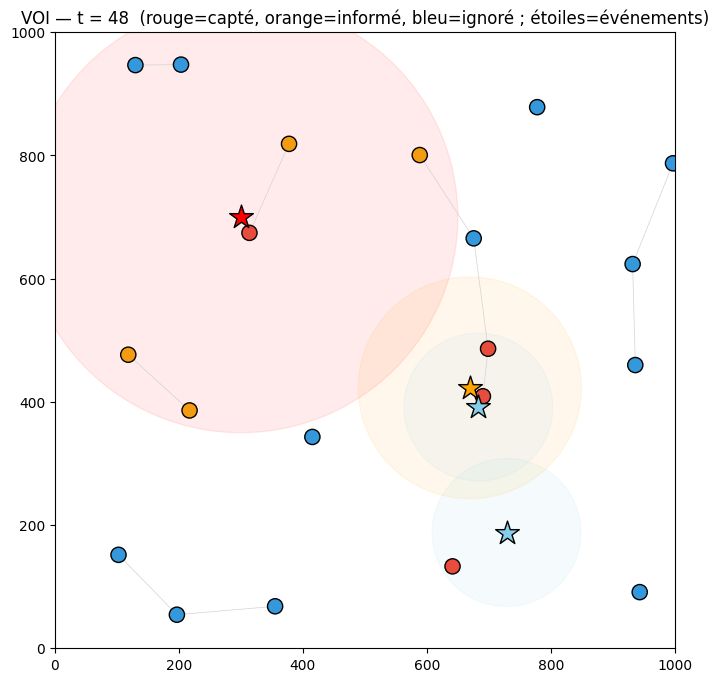

In [9]:
from IPython import display
import time

proto_vu = 'voi'                       # protocole à visualiser : 'flooding' / 'gossip' / 'voi'
couleurs_hist = resultats[proto_vu]['couleurs']

fig, ax = plt.subplots(figsize=(8, 8))
for t in range(0, cfg['steps'], 2):
    ax.clear()
    positions = traj[t]
    G = graphe_proximite(positions, cfg['R'])
    for a, b in G.edges():
        ax.plot([positions[a, 0], positions[b, 0]], [positions[a, 1], positions[b, 1]],
                color='lightgray', linewidth=0.5, zorder=1)
    for e in events:
        if e.actif(t):
            ax.add_patch(plt.Circle(e.pos, e.relevance, color=e.couleur, alpha=0.08, zorder=0))
            ax.scatter(*e.pos, c=e.couleur, marker='*', s=320, edgecolors='black', zorder=5)
    ax.scatter(positions[:, 0], positions[:, 1], c=couleurs_hist[t], s=120,
               edgecolors='black', zorder=4)
    ax.set_xlim(0, tailleMap); ax.set_ylim(0, tailleMap)
    ax.set_title(f'{proto_vu.upper()} — t = {t}  '
                 f'(rouge=capté, orange=informé, bleu=ignoré ; étoiles=événements)')
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.08)
display.display(fig); plt.close(fig)


### Lire les résultats

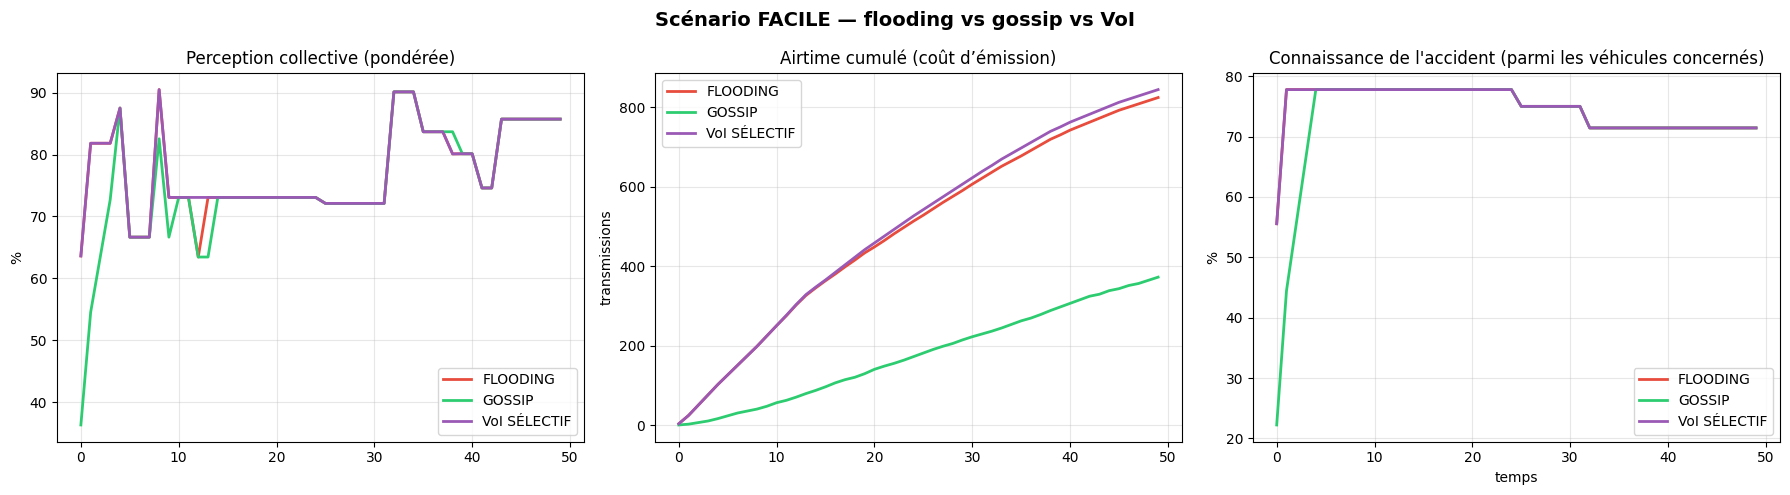

In [10]:
titres = {'flooding': 'FLOODING', 'gossip': 'GOSSIP', 'voi': 'VoI SÉLECTIF'}
couleurs = {'flooding': '#e74c3c', 'gossip': '#2ecc71', 'voi': '#9b59b6'}

# Modification de la grille : 1 ligne de 3 graphiques au lieu de 2x2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for p in protocols:
    axes[0].plot(resultats[p]['cov'], label=titres[p], color=couleurs[p], linewidth=2)
axes[0].set_title('Perception collective (pondérée)'); axes[0].set_ylabel('%')
axes[0].legend(); axes[0].grid(alpha=0.3)

for p in protocols:
    axes[1].plot(np.cumsum(resultats[p]['tx']), label=titres[p], color=couleurs[p], linewidth=2)
axes[1].set_title('Airtime cumulé (coût d’émission)'); axes[1].set_ylabel('transmissions')
axes[1].legend(); axes[1].grid(alpha=0.3)

for p in protocols:
    axes[2].plot(resultats[p]['crit'], label=titres[p], color=couleurs[p], linewidth=2)
axes[2].set_title("Connaissance de l'accident (parmi les véhicules concernés)")
axes[2].set_xlabel('temps'); axes[2].set_ylabel('%'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Scénario {CHOIX.upper()} — flooding vs gossip vs VoI', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()



### **Analyse des résultats et limites du VoI sélectif**

En observant les graphiques ci-dessus, un constat s'impose : bien que le **VoI SÉLECTIF** surpasse les autres approches en termes de perception collective et de réactivité face à l'accident, sa courbe d'**Airtime cumulé** reste pratiquement confondue avec celle du *Flooding*. 

C'est pour remédier à cette surconsommation de bande passante et éviter de propager des données locales à l'échelle d'une carte entière que nous allons maintenant étudier une approche géographique différente : le découpage de notre terrain en **zones locales** encadrées par des **RSU (Roadside Units)**.

## 5. L'infrastructure repensée : des **zones locales**, chacune avec sa RSU

Sur une carte 1000×1000, propager une info à un véhicule très loin n'a aucun sens. On découpe donc la carte en **zones locales** (une grille `grid × grid`), chacune dotée de **sa propre RSU** au centre. La diffusion se fait alors à **deux niveaux** :

**Niveau 1 — à l'intérieur d'une zone.** Les véhicules diffusent entre eux (flooding / gossip / VoI). La RSU de la zone **collecte** ce que les véhicules à sa portée lui remontent (V2I) et le **rediffuse** aux véhicules de sa zone (I2V), avec un gros budget et une mémoire quasi illimitée. C'est le rôle « désenclaver localement ».

**Niveau 2 — le *backbone* entre RSU.** Une info ne peut passer d'une zone à l'autre **que** via les RSU. Une RSU relaie un événement à une RSU voisine **seulement si** :
1. elles sont **à portée** : `distance(RSU_i, RSU_j) ≤ R_RSU` ;
2. l'événement **concerne géographiquement** la zone d'arrivée : `cercle_touche_zone(event, zone_voisine)`.

> **Le point clé (et la réponse au dilemme « tout relayer = gaspiller / rien relayer = inutile »).** La règle (2) n'est rien d'autre que le concept de **pertinence**, transposé du véhicule à la zone : au niveau 1 on teste `pertinent(position_véhicule, e)` ; au niveau 2 on teste si le **halo de l'événement déborde dans la zone voisine**. Les RSU ne forment donc pas un flooding aveugle : elles ne relaient un événement vers une zone que **lorsque des véhicules de cette zone seraient réellement concernés**. La diffusion inter-zones reste bornée par la géographie, exactement comme la diffusion intra-zone.

Le backbone est lui-même **VoI-sélectif** : sous congestion, une RSU relaie en priorité ses événements de plus forte valeur. Avec `grid=1`, on retombe sur l'ancien modèle : **une seule RSU centrale**, sans backbone.

**Réglage par défaut (grille 2×2).** 4 zones de 500×500, RSU aux centres (250,250)/(750,250)/(250,750)/(750,750). Avec `R_RSU = 550`, on relie les RSU **orthogonales** (distance 500 ✓) mais **pas les diagonales** (distance 707 ✗) : le backbone forme un **anneau** RSU0–RSU1–RSU3–RSU2–RSU0, et une info qui doit traverser en diagonale fait **2 sauts** de RSU.


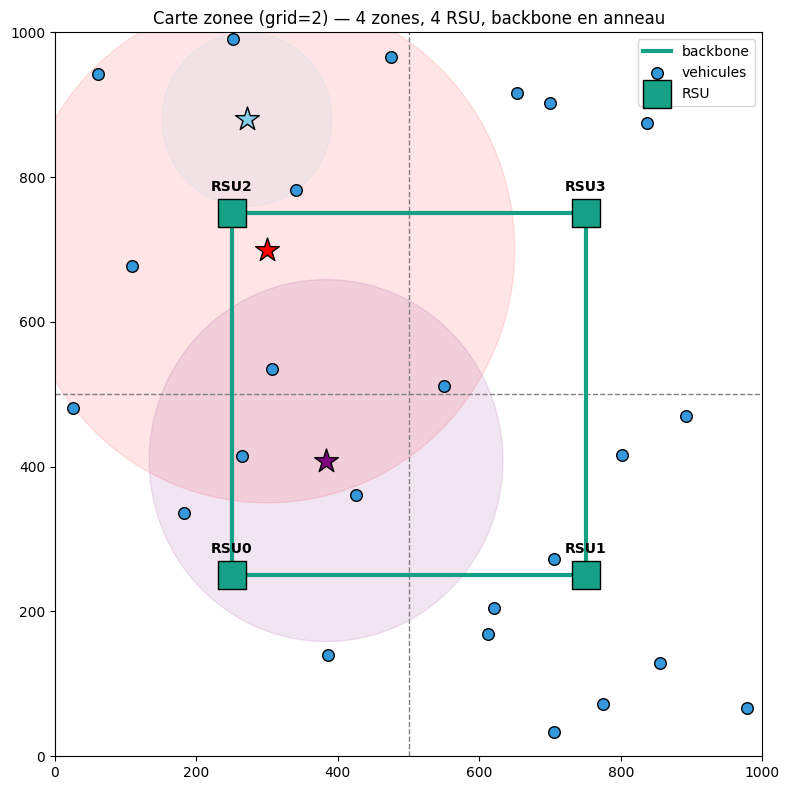

--- Scenario fragmente (R=130) ---
SANS RSU                  : perception  27.6% | accident  17.8%
RSU centrale (grid=1)     : perception  53.9% | accident  91.3%
RSU multi-zones (grid=2)  : perception  55.5% | accident  98.2%


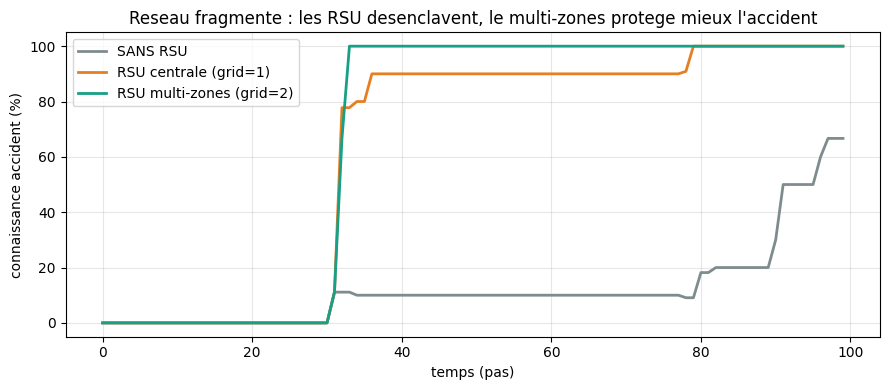

In [13]:
frag = dict(N=24, R=130, R_sense=90, MAX_TX=2, n_events=10, vmax=7, steps=100,
            grid=2, R_RSU=550, RSU_TX=15, RSU_BB_TX=20,
            MAX_RX=2, RSU_RX=40) 

traj_f  = generer_positions(frag['N'], frag['steps'], frag['vmax'], tailleMap, seed=5)
events_f = make_events(frag['n_events'], frag['steps'], tailleMap, seed=5)

# ---- (i) Carte zonee : 4 zones, 4 RSU, backbone, et halos de pertinence des evenements ----
rsu_pos, zones = make_rsus(frag['grid'], tailleMap)
t_vu = 30 #l'affichage de notre carte se fait à t_vu 
positions = traj_f[t_vu]; cell = tailleMap/frag['grid']
fig, ax = plt.subplots(figsize=(8,8))

# Tracé des lignes de séparation des zones
for k in range(1, frag['grid']):
    ax.axvline(k*cell, color='gray', ls='--', lw=1); ax.axhline(k*cell, color='gray', ls='--', lw=1)

# Tracé du backbone (liens RSU-RSU à portée)
for r in range(len(rsu_pos)):
    for s in range(r+1, len(rsu_pos)):
        if np.linalg.norm(rsu_pos[r]-rsu_pos[s]) <= frag['R_RSU']:
            ax.plot([rsu_pos[r,0],rsu_pos[s,0]],[rsu_pos[r,1],rsu_pos[s,1]],
                    color='#16a085', lw=3, zorder=2, label='backbone' if (r,s)==(0,1) else None)

# Affichage des événements actifs au temps t_vu
for e in events_f:
    if e.actif(t_vu):
        ax.add_patch(plt.Circle(e.pos, e.relevance, color=e.couleur, alpha=0.10, zorder=0))
        ax.scatter(*e.pos, c=e.couleur, marker='*', s=320, edgecolors='black', zorder=4)

# Affichage des véhicules et des RSUs
ax.scatter(positions[:,0], positions[:,1], c='#3498db', s=70, edgecolors='black', zorder=3, label='vehicules')
ax.scatter(rsu_pos[:,0], rsu_pos[:,1], c='#16a085', marker='s', s=420, edgecolors='black', zorder=5, label='RSU')

# Annotations pour identifier chaque RSU
for r in range(len(rsu_pos)):
    ax.annotate(f'RSU{r}', rsu_pos[r], textcoords="offset points", xytext=(0,16), ha='center', fontweight='bold')

ax.set_xlim(0,tailleMap); ax.set_ylim(0,tailleMap); ax.legend(loc='upper right')
ax.set_title(f'Carte zonee (grid={frag["grid"]}) — 4 zones, 4 RSU, backbone en anneau')
plt.tight_layout(); plt.show()

# ---- (ii) Comparaison : sans RSU vs RSU centrale (grid=1) vs RSU multi-zones (grid=2) ----
configs = [('SANS RSU', frag, False),
           ('RSU centrale (grid=1)', {**frag, 'grid':1}, True),
           ('RSU multi-zones (grid=2)', frag, True)]

print(f"--- Scenario fragmente (R={frag['R']}) ---")
res_rsu = {}
for tag, c, use in configs:
    r = simuler('voi', c, events_f, traj_f, use_rsu=use)
    res_rsu[tag] = r
    acc = np.mean([x for x in r['crit'] if x > 0] or [0])
    print(f"{tag:26s}: perception {np.mean(r['cov']):5.1f}% | accident {acc:5.1f}%")

# ---- (iii) Courbes : connaissance de l'accident au cours du temps ----
plt.figure(figsize=(9,4))
cols = {'SANS RSU':'#7f8c8d','RSU centrale (grid=1)':'#e67e22','RSU multi-zones (grid=2)':'#16a085'}
for tag in res_rsu:
    plt.plot(res_rsu[tag]['crit'], label=tag, color=cols[tag], lw=2)
plt.xlabel('temps (pas)'); plt.ylabel("connaissance accident (%)")
plt.title("Reseau fragmente : les RSU desenclavent, le multi-zones protege mieux l'accident")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Conclusion du TP2

**Partie A — percevoir (le S de l'ISAC).** La perception devient **collective** : un véhicule connaît des événements qu'il ne peut pas voir lui-même, parce qu'un voisin les a détectés et partagés (CPM). C'est l'intérêt central de l'ISAC, et il est **mesurable** (gain de plusieurs dizaines de points de perception).

**Partie B — choisir sous contraintes.** Sous des hypothèses **réalistes** (âge depuis l'observation, zone de pertinence ), la diffusion sélective (VoI) **n'est pas magiquement moins chère** que le flooding : à budget égal, l'airtime est comparable. Son intérêt est ailleurs : sous congestion, elle ne **sacrifie aucune information utile** et fait remonter en priorité l'**information critique**.

**L'infrastructure zonée.** Plutôt qu'une RSU centrale unique, on découpe la carte en **zones locales** dotées chacune de leur RSU, organisées en **deux niveaux** : diffusion locale dans la zone, et **backbone** entre RSU. Le backbone n'est **pas** un flooding : il est **VoI-sélectif** et borné par la **pertinence-zone** — une info ne franchit une frontière de zone que si elle y concerne réellement quelqu'un.


## Ouverture : TP3 — Vers l'IA adaptative

Pour le **TP3**, nous évoluerons vers une approche adaptative grâce au **Q-Learning**. Au lieu de suivre des règles de transmission fixes, chaque véhicule embarquera un petit « cerveau » capable d'apprendre par lui-même. Par un mécanisme d'apprentissage par renforcement, le véhicule testera différentes décisions et recevra des récompenses, construisant progressivement un tableau de scores. Cette IA légère, sans réseau de neurones complexe, permettra au véhicule d'optimiser ses décisions de transmission en temps réel selon la situation rencontrée.
